# Quickstart Notebook

This notebook loads a CSV dataset using the shared dataloader utilities.

In [83]:
from pathlib import Path
import sys

# Ensure project root is on sys.path for imports
project_root = Path("../..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from dataloader import load_txt, preprocess, GWASDataset

data_path = Path("../../data/tmpDATA-Leon/donnees_MRI_SCZ_only_variants_clumping_p_thr_0.0001all.txt")

df = load_txt(data_path)
df.head(5)


,Mean_intensity_3rd-Ventricle_whole-brain,Mean_intensity_4th-Ventricle_whole-brain,Mean_intensity_Brain-Stem_whole-brain,Mean_intensity_CSF_whole-brain,Mean_intensity_WM-hypointensities_whole-brain,Mean_intensity_Optic-Chiasm_whole-brain,Mean_intensity_CC-Posterior_whole-brain,Mean_intensity_CC-Mid-Posterior_whole-brain,Mean_intensity_CC-Central_whole-brain,Mean_intensity_CC-Mid-Anterior_whole-brain,...,Volume_S-postcentral_right,Volume_S-precentral-inf-part_right,Volume_S-precentral-sup-part_right,Volume_S-suborbital_right,Volume_S-subparietal_right,Volume_S-temporal-inf_right,Volume_S-temporal-sup_right,Volume_S-temporal-transverse_right,Z_scores_SCZ,ID
0,0.608651,0.417999,0.069745,0.118751,0.035988,-0.739803,1.208980,1.231560,0.780141,1.146150,...,-2.36435,-2.666830,0.707186,1.571280,-1.005540,-1.459920,-1.380530,-0.675617,3.980516,rs75878372
1,1.415920,1.123030,1.282310,1.587510,-0.347488,1.563280,2.182110,2.276960,1.213580,0.518312,...,-2.64181,-2.550490,-0.034571,0.555264,-0.749748,-3.499360,-3.379250,-1.665300,4.142574,rs150264563
2,-0.110527,-1.008280,-0.197095,-0.319888,0.126057,0.810311,-0.117957,-0.610847,-0.540175,-1.002590,...,-1.02813,0.272983,0.795672,-0.755772,0.135706,-0.654114,-0.153661,1.155150,3.974909,rs74911850
3,2.009210,1.407730,-0.855615,2.096700,-0.739741,-2.170680,0.553276,-0.059186,0.518272,0.902127,...,-1.09760,-1.469710,-2.289510,0.554313,1.490930,0.134280,0.404540,0.211052,3.928370,rs56086712
4,0.037307,-0.638911,-2.213110,-0.499057,-0.203933,-1.978070,1.718970,0.119012,-0.343785,0.134792,...,0.17855,-1.655620,-1.104240,0.955359,2.738340,0.903522,0.922400,1.136840,4.455699,rs17731


In [84]:
# convert the Z_score column to binary labels based on a threshold at 0
df["Z_scores_SCZ"] = (df["Z_scores_SCZ"] > 0).astype(int)

In [85]:
df.head(5)

,Mean_intensity_3rd-Ventricle_whole-brain,Mean_intensity_4th-Ventricle_whole-brain,Mean_intensity_Brain-Stem_whole-brain,Mean_intensity_CSF_whole-brain,Mean_intensity_WM-hypointensities_whole-brain,Mean_intensity_Optic-Chiasm_whole-brain,Mean_intensity_CC-Posterior_whole-brain,Mean_intensity_CC-Mid-Posterior_whole-brain,Mean_intensity_CC-Central_whole-brain,Mean_intensity_CC-Mid-Anterior_whole-brain,...,Volume_S-postcentral_right,Volume_S-precentral-inf-part_right,Volume_S-precentral-sup-part_right,Volume_S-suborbital_right,Volume_S-subparietal_right,Volume_S-temporal-inf_right,Volume_S-temporal-sup_right,Volume_S-temporal-transverse_right,Z_scores_SCZ,ID
0,0.608651,0.417999,0.069745,0.118751,0.035988,-0.739803,1.208980,1.231560,0.780141,1.146150,...,-2.36435,-2.666830,0.707186,1.571280,-1.005540,-1.459920,-1.380530,-0.675617,1,rs75878372
1,1.415920,1.123030,1.282310,1.587510,-0.347488,1.563280,2.182110,2.276960,1.213580,0.518312,...,-2.64181,-2.550490,-0.034571,0.555264,-0.749748,-3.499360,-3.379250,-1.665300,1,rs150264563
2,-0.110527,-1.008280,-0.197095,-0.319888,0.126057,0.810311,-0.117957,-0.610847,-0.540175,-1.002590,...,-1.02813,0.272983,0.795672,-0.755772,0.135706,-0.654114,-0.153661,1.155150,1,rs74911850
3,2.009210,1.407730,-0.855615,2.096700,-0.739741,-2.170680,0.553276,-0.059186,0.518272,0.902127,...,-1.09760,-1.469710,-2.289510,0.554313,1.490930,0.134280,0.404540,0.211052,1,rs56086712
4,0.037307,-0.638911,-2.213110,-0.499057,-0.203933,-1.978070,1.718970,0.119012,-0.343785,0.134792,...,0.17855,-1.655620,-1.104240,0.955359,2.738340,0.903522,0.922400,1.136840,1,rs17731


In [87]:
X_train, y_train, X_test, y_test = preprocess(df=df, target="Z_scores_SCZ", testsize = 0.2)


In [88]:
y_train

1566    0
3293    1
1652    0
1784    1
2564    0
       ..
1130    1
1294    0
860     1
3507    1
3174    1
Name: Z_scores_SCZ, Length: 2826, dtype: int64

In [89]:
# run logistic regression as baseline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.72      0.71       337
           1       0.74      0.72      0.73       370

    accuracy                           0.72       707
   macro avg       0.72      0.72      0.72       707
weighted avg       0.72      0.72      0.72       707



In [90]:
# run random forest as baseline
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.68      0.64      0.66       337
           1       0.69      0.72      0.70       370

    accuracy                           0.68       707
   macro avg       0.68      0.68      0.68       707
weighted avg       0.68      0.68      0.68       707



In [98]:
from xgboost import XGBClassifier
# read data
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# create model instance
bst = XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1, objective='binary:logistic')
# fit model
bst.fit(X_train, y_train)
# make predictions
preds = bst.predict(X_test)
print(classification_report(y_test, preds))


              precision    recall  f1-score   support

           0       0.61      0.51      0.56       337
           1       0.61      0.70      0.65       370

    accuracy                           0.61       707
   macro avg       0.61      0.61      0.60       707
weighted avg       0.61      0.61      0.61       707



In [99]:
from torch.utils.data import DataLoader

train_loader = DataLoader(GWASDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(GWASDataset(X_test, y_test), batch_size=32, shuffle=False)

In [105]:
from model import DNN
from torch import nn, optim

model = DNN(input_dim=X_train.shape[1], hidden_dims=[100, 100], output_dim=1, dropout=0.5, activation_function=nn.ReLU())
print(model)

DNN(
  (network): Sequential(
    (0): Linear(in_features=1010, out_features=100, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=100, out_features=100, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.5, inplace=False)
    (8): Linear(in_features=100, out_features=1, bias=True)
  )
)


In [106]:
from torch import nn, optim
import torch

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.000005)

train_losses = []
test_losses = []
 
for epoch in range(200):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch_X.size(0)
    train_losses.append(total_loss / len(train_loader.dataset))
    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader.dataset):.4f}")

    model.eval()
    test_loss = 0
 
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            test_loss += loss.item() * batch_X.size(0)
    
    average_test_loss = test_loss / len(test_loader.dataset)
    test_losses.append(average_test_loss)
    print(f"Test Loss: {average_test_loss:.4f}")

Epoch 1, Loss: 0.7491
Test Loss: 0.6871
Epoch 2, Loss: 0.7286
Test Loss: 0.6811
Epoch 3, Loss: 0.7203
Test Loss: 0.6753
Epoch 4, Loss: 0.7238
Test Loss: 0.6677
Epoch 5, Loss: 0.7279
Test Loss: 0.6636
Epoch 6, Loss: 0.6979
Test Loss: 0.6598
Epoch 7, Loss: 0.6905
Test Loss: 0.6557
Epoch 8, Loss: 0.7007
Test Loss: 0.6509
Epoch 9, Loss: 0.6913
Test Loss: 0.6480
Epoch 10, Loss: 0.6946
Test Loss: 0.6460
Epoch 11, Loss: 0.6793
Test Loss: 0.6437
Epoch 12, Loss: 0.6671
Test Loss: 0.6418
Epoch 13, Loss: 0.6664
Test Loss: 0.6389
Epoch 14, Loss: 0.6729
Test Loss: 0.6365
Epoch 15, Loss: 0.6640
Test Loss: 0.6353
Epoch 16, Loss: 0.6576
Test Loss: 0.6342
Epoch 17, Loss: 0.6622
Test Loss: 0.6312
Epoch 18, Loss: 0.6617
Test Loss: 0.6299
Epoch 19, Loss: 0.6454
Test Loss: 0.6272
Epoch 20, Loss: 0.6536
Test Loss: 0.6258
Epoch 21, Loss: 0.6406
Test Loss: 0.6254
Epoch 22, Loss: 0.6443
Test Loss: 0.6243
Epoch 23, Loss: 0.6284
Test Loss: 0.6225
Epoch 24, Loss: 0.6415
Test Loss: 0.6207
Epoch 25, Loss: 0.6367
Te

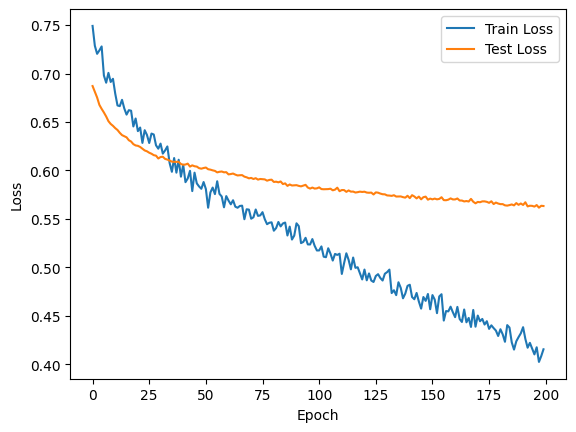

In [107]:
# plot training and test losses
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [108]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report


# get the r2 score of the dnn model on test set
logits = model(torch.tensor(X_test, dtype=torch.float32)).detach()
# print accuracy and other metricsfrom sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Convert predicted probabilities to binary predictions
y_pred_binary = (logits >= 0)

# Metrics
accuracy = accuracy_score(y_test, y_pred_binary)
precision = precision_score(y_test, y_pred_binary)
recall = recall_score(y_test, y_pred_binary)
f1 = f1_score(y_test, y_pred_binary)
roc_auc = roc_auc_score(y_test, y_pred_binary)

print("=" * 40)
print("         Model Evaluation Metrics")
print("=" * 40)
print(f"  Accuracy:    {accuracy:.4f}")
print(f"  Precision:   {precision:.4f}")
print(f"  Recall:      {recall:.4f}")
print(f"  F1 Score:    {f1:.4f}")
print(f"  ROC AUC:     {roc_auc:.4f}")
print("=" * 40)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_binary))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_binary, target_names=['No Illness', 'Illness']))


         Model Evaluation Metrics
  Accuracy:    0.7001
  Precision:   0.7124
  Recall:      0.7162
  F1 Score:    0.7143
  ROC AUC:     0.6994

Confusion Matrix:
[[230 107]
 [105 265]]

Classification Report:
              precision    recall  f1-score   support

  No Illness       0.69      0.68      0.68       337
     Illness       0.71      0.72      0.71       370

    accuracy                           0.70       707
   macro avg       0.70      0.70      0.70       707
weighted avg       0.70      0.70      0.70       707



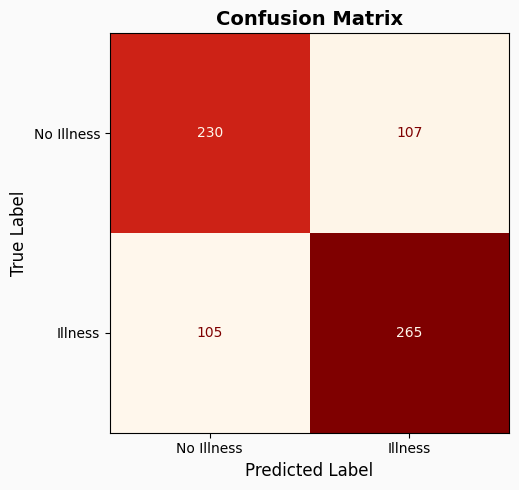

In [109]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred_binary)

fig, ax = plt.subplots(figsize=(6, 5))
ax.set_facecolor('#f0f0f0')
fig.patch.set_facecolor('#fafafa')

disp = ConfusionMatrixDisplay(cm, display_labels=['No Illness', 'Illness'])
disp.plot(ax=ax, cmap='OrRd', values_format='d', colorbar=False)

ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.show()